# 8. Panorama Retrieval

Fetches Amsterdam street-level panorama images for each tile in `SETUP_TILECODES`.

For each tile, the nearest 2024 panorama is found via the Amsterdam REST API and cached locally.
Camera pose (heading, pitch, roll) is saved alongside the image for use in notebook 9.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

sys.path.insert(0, str(Path.cwd()))
import config
from utils.panorama_api import (
    fetch_panoramas_in_tile, download_panorama_image,
    rd_to_wgs84, wgs84_to_rd,
)


## Configuration

In [ ]:
PANO_DIR = Path("data/input/panoramas")
PANO_DIR.mkdir(parents=True, exist_ok=True)

MISSION_YEAR  = 2024    # change to None to allow any year
MIN_SPACING_M = 4.0     # minimum distance between panoramas kept per tile (metres).
                         # Cyclomedia captures roughly every 5m along the driving
                         # path, so 4m keeps nearly every available frame (going
                         # lower has ~no further effect — there usually isn't a
                         # frame that close). Tested on tile 119900_489300 against
                         # the previous 8.0m default: 13->25 panoramas, and 28->43
                         # distinct objects triangulated from >=2 camera views
                         # (+54%), for 2x fetch/detection time and image cache size.
                         # Triangulation itself additionally rejects camera pairs
                         # closer than MIN_BASELINE_M=3m in notebook 9/4.9, so this
                         # doesn't waste triangulation effort on near-duplicate pairs.
BUFFER_M      = 30.0    # grow the tile footprint by this much when searching for
                         # cameras — panoramas are 360°, so a camera just outside
                         # the tile can still see everything inside it. Empirically
                         # this made no difference for the example tile (the search
                         # radius was already large enough), but it's a cheap safety
                         # margin for tiles where the street runs along the edge.
IMAGE_SIZE    = "medium" # 'small' (2000px), 'medium' (4000px), 'full' (8000px)
FORCE_REFETCH = False    # set True to ignore cached panoramas.json and re-query
                         # the API (e.g. after changing BUFFER_M/MIN_SPACING_M)

TILECODES = config.SETUP_TILECODES
print(f"Processing {len(TILECODES)} tiles.")

## Fetch panoramas for each tile

In [3]:
from tqdm import tqdm

# results: flat list of pose dicts; each pose has a "tilecode" key
results = []

for tilecode in tqdm(TILECODES, desc="Fetching panoramas"):
    tile_pano_dir = PANO_DIR / tilecode
    cache_path = tile_pano_dir / "panoramas.json"

    if cache_path.exists() and not FORCE_REFETCH:
        with open(cache_path) as f:
            poses = json.load(f)
        results.extend(poses)
        print(f"  {tilecode}: {len(poses)} panoramas (cached)")
        continue

    poses = fetch_panoramas_in_tile(
        tilecode,
        bbox_dir=config.BBOX_DIR,
        mission_year=MISSION_YEAR,
        min_spacing_m=MIN_SPACING_M,
        buffer_m=BUFFER_M,
    )
    if not poses:
        print(f"  {tilecode}: no panoramas found")
        continue

    tile_pano_dir.mkdir(parents=True, exist_ok=True)

    # Download images
    for pose in poses:
        download_panorama_image(pose, size=IMAGE_SIZE, cache_dir=tile_pano_dir)

    # Cache metadata as a list
    with open(cache_path, "w") as f:
        json.dump(poses, f, indent=2)

    results.extend(poses)
    print(f"  {tilecode}: {len(poses)} panoramas fetched")

print(f"\nDone. {len(results)} panoramas across {len(TILECODES)} tiles.")


Fetching panoramas: 100%|██████████| 9/9 [00:00<00:00, 2277.31it/s]

  120300_489300: 12 panoramas (cached)
  120300_488900: 13 panoramas (cached)
  120700_489300: 12 panoramas (cached)
  119900_489300: 12 panoramas (cached)
  120300_489700: 13 panoramas (cached)
  121100_484900: 13 panoramas (cached)
  121500_484900: 10 panoramas (cached)
  121100_485300: 10 panoramas (cached)
  121500_485300: 12 panoramas (cached)

Done. 107 panoramas across 9 tiles.


## Verify: show first panorama

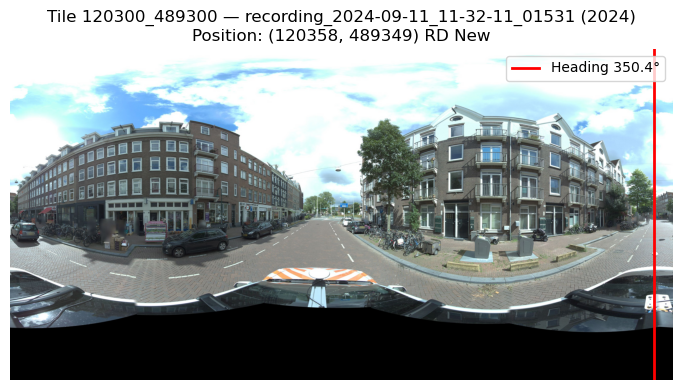

Heading: 350.4°  Pitch: 0.00°  Roll: 0.00°
Image size: 4000×2000
(12 panoramas total for this tile)


In [4]:
import math
from PIL import Image

if results:
    pose = results[0]
    tilecode = pose["tilecode"]
    img_path = next((PANO_DIR / tilecode).glob("*.jpg"), None)

    if img_path:
        img_arr = np.array(Image.open(img_path).convert("RGB"))
        H, W = img_arr.shape[:2]
        heading_px = int(pose["heading"] / 360.0 * W)

        fig, ax = plt.subplots(figsize=(16, 4))
        ax.imshow(img_arr)
        ax.axvline(heading_px, color="red", linewidth=2,
                   label=f'Heading {pose["heading"]:.1f}°')
        ax.set_title(
            f'Tile {tilecode} — {pose["pano_id"]} ({pose["mission_year"]})\n'
            f'Position: ({pose["x_rd"]:.0f}, {pose["y_rd"]:.0f}) RD New'
        )
        ax.legend(loc="upper right")
        ax.axis("off")
        plt.tight_layout()
        plt.show()
        print(f'Heading: {pose["heading"]:.1f}°  Pitch: {pose["pitch"]:.2f}°  '
              f'Roll: {pose["roll"]:.2f}°')
        print(f'Image size: {W}×{H}')
        print(f'({len([r for r in results if r["tilecode"] == tilecode])} '
              f'panoramas total for this tile)')
    else:
        print("No image file found.")


## Panorama coverage map

Show camera positions overlaid on the tile grid.

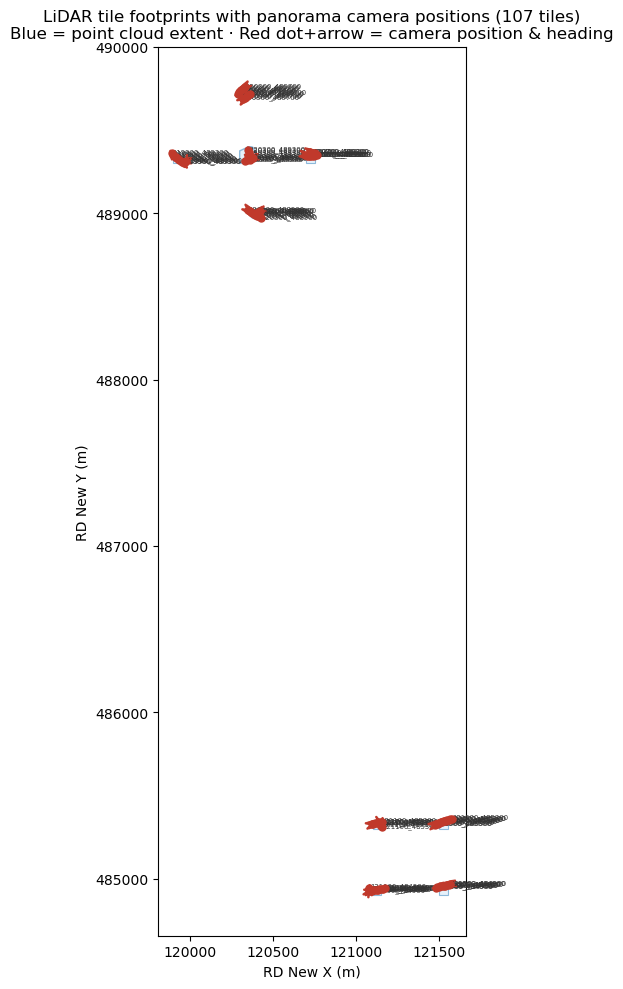

In [5]:
import json as _json
from matplotlib.patches import Polygon as MplPolygon
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))

# Draw actual LiDAR tile footprints from bbox GeoJSON files
for tc in TILECODES:
    bbox_path = config.BBOX_DIR / f"bbox_{tc}.geojson"
    if bbox_path.exists():
        with open(bbox_path) as f:
            geojson = _json.load(f)
        for feature in geojson.get("features", []):
            coords = feature["geometry"]["coordinates"][0]  # outer ring
            xy = np.array(coords)
            poly = MplPolygon(xy, closed=True,
                              facecolor="#d6e8f7", edgecolor="#4a90c4",
                              linewidth=1.0, alpha=0.6)
            ax.add_patch(poly)
    else:
        # Fallback: 50×50 m bounding box when no bbox file exists
        parts = tc.split("_")
        x0, y0 = float(parts[0]), float(parts[1])
        rect = plt.Rectangle((x0, y0), 50, 50,
                              facecolor="#d6e8f7", edgecolor="#4a90c4",
                              linewidth=0.8, alpha=0.6)
        ax.add_patch(rect)

# Draw camera positions with heading arrows
for pose in results:
    cx, cy = pose["x_rd"], pose["y_rd"]
    h_rad = math.radians(pose["heading"])
    dx, dy = math.sin(h_rad) * 18, math.cos(h_rad) * 18
    ax.annotate("", xy=(cx + dx, cy + dy), xytext=(cx, cy),
                arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.8))
    ax.plot(cx, cy, "o", color="#c0392b", markersize=5, zorder=5)
    ax.text(cx + 2, cy + 2, pose["tilecode"], fontsize=5, color="#333333")

ax.autoscale()
ax.set_aspect("equal")
ax.set_xlabel("RD New X (m)")
ax.set_ylabel("RD New Y (m)")
ax.set_title(
    f"LiDAR tile footprints with panorama camera positions ({len(results)} tiles)\n"
    f"Blue = point cloud extent · Red dot+arrow = camera position & heading"
)
plt.tight_layout()
plt.show()
